# 08 - Final Model Evaluation

## Objective

This notebook performs the final, one-time evaluation of the model selected in Notebook 07.

It:

- loads the frozen V1 candidate configuration;
- retrains that model using January-October 2025 data;
- applies the frozen decision threshold to November-December 2025;
- reports the proposal-required classification, ranking, and calibration metrics;
- saves the fitted Python model, preprocessing pipeline, metadata, and evaluation tables.

No algorithm selection, hyperparameter tuning, feature selection, calibration fitting, or threshold search is performed here.


## Scope Boundary

Notebook 07 owns model selection, the decision threshold, and the validation-derived operational risk bands. Notebook 08 only verifies the frozen decision on the holdout period.

The holdout labels are used once, after the model parameters and threshold have been loaded from the Notebook 07 artifacts. The results from this notebook must not be used to retune the model.


## Load Project Configuration and Libraries


In [25]:
from __future__ import annotations

import gc
import importlib.util
import io
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from databricks.sdk import WorkspaceClient
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not bootstrap.is_file():
    bootstrap = Path.cwd() / "import_path.py"

spec = importlib.util.spec_from_file_location("import_path", bootstrap)
import_path = importlib.util.module_from_spec(spec)
spec.loader.exec_module(import_path)

from config import project_config as cfg
from dotenv import dotenv_values
from utils.model_evaluation import (
    calibration_summary,
    lift_at_top_percentiles,
    subgroup_error_analysis,
)
from utils.python_model_training import (
    build_estimator,
    classification_metrics,
    prepare_model_matrices,
)

DATABRICKS_PROFILE = os.getenv(
    "DATABRICKS_CONFIG_PROFILE", "capstone-serverless"
)
api_env_candidates = [
    Path.cwd() / "api" / ".env",
    Path.cwd().parent / "api" / ".env",
]
api_env_path = next(
    (candidate for candidate in api_env_candidates if candidate.is_file()),
    None,
)
api_credentials = dotenv_values(api_env_path) if api_env_path else {}
LOCAL_DATABRICKS_HOST = str(
    api_credentials.get("DATABRICKS_SERVER_HOSTNAME", "")
).strip()
LOCAL_DATABRICKS_TOKEN = str(
    api_credentials.get("DATABRICKS_ACCESS_TOKEN", "")
).strip()
if LOCAL_DATABRICKS_HOST and not LOCAL_DATABRICKS_HOST.startswith("http"):
    LOCAL_DATABRICKS_HOST = f"https://{LOCAL_DATABRICKS_HOST}"

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession

    builder = DatabricksSession.builder.serverless()
    if LOCAL_DATABRICKS_HOST and LOCAL_DATABRICKS_TOKEN:
        builder = builder.host(LOCAL_DATABRICKS_HOST).token(
            LOCAL_DATABRICKS_TOKEN
        )
    else:
        builder = builder.profile(DATABRICKS_PROFILE)
    spark = builder.getOrCreate()

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

print("Project configuration, Spark session, and Python libraries loaded.")


Project configuration, Spark session, and Python libraries loaded.


## Load and Validate the Frozen Notebook 07 Candidate


In [26]:
def read_json_artifact(path: str) -> dict:
    rows = spark.read.text(path).collect()
    if not rows:
        raise RuntimeError(f"Required JSON artifact is empty: {path}")
    return json.loads("\n".join(row["value"] for row in rows))


candidate_selection = read_json_artifact(cfg.CANDIDATE_SELECTION_PATH)
feature_manifest = read_json_artifact(cfg.MODEL_FEATURE_MANIFEST_PATH)

required_candidate_keys = {
    "selected_model",
    "parameters",
    "decision_threshold",
    "risk_thresholds",
    "validation_metrics",
}
missing_candidate_keys = sorted(
    required_candidate_keys - set(candidate_selection)
)
if missing_candidate_keys:
    raise ValueError(
        f"Candidate artifact is missing keys: {missing_candidate_keys}"
    )

required_manifest_keys = {
    "categorical_features",
    "numerical_features",
    "target",
}
missing_manifest_keys = sorted(
    required_manifest_keys - set(feature_manifest)
)
if missing_manifest_keys:
    raise ValueError(
        f"Feature manifest is missing keys: {missing_manifest_keys}"
    )

SELECTED_MODEL_NAME = candidate_selection["selected_model"]
SELECTED_MODEL_PARAMETERS = dict(candidate_selection["parameters"])
SELECTED_THRESHOLD = float(candidate_selection["decision_threshold"])
RISK_THRESHOLDS = dict(candidate_selection["risk_thresholds"])
MEDIUM_RISK_THRESHOLD = float(RISK_THRESHOLDS["medium"])
HIGH_RISK_THRESHOLD = float(RISK_THRESHOLDS["high"])
CRITICAL_RISK_THRESHOLD = float(RISK_THRESHOLDS["critical"])
CATEGORICAL_COLUMNS = list(feature_manifest["categorical_features"])
NUMERICAL_COLUMNS = list(feature_manifest["numerical_features"])
TARGET_COLUMN = feature_manifest["target"]
DATE_COLUMN = cfg.FLIGHT_DATE_COLUMN
MODEL_COLUMNS = CATEGORICAL_COLUMNS + NUMERICAL_COLUMNS

if SELECTED_MODEL_NAME != "XGBoost":
    raise ValueError(
        "The canonical V1 artifact must select XGBoost before Notebook 08 runs. "
        f"Found: {SELECTED_MODEL_NAME}"
    )
if not 0.0 < SELECTED_THRESHOLD < 1.0:
    raise ValueError(f"Invalid frozen threshold: {SELECTED_THRESHOLD}")
if not (
    0.0 < MEDIUM_RISK_THRESHOLD <= HIGH_RISK_THRESHOLD
    < CRITICAL_RISK_THRESHOLD <= 1.0
):
    raise ValueError(f"Invalid frozen risk thresholds: {RISK_THRESHOLDS}")
if not np.isclose(MEDIUM_RISK_THRESHOLD, SELECTED_THRESHOLD):
    raise ValueError(
        "Medium-risk threshold must equal the frozen decision threshold."
    )
if TARGET_COLUMN != cfg.TARGET_COLUMN:
    raise ValueError(
        f"Manifest target {TARGET_COLUMN} does not match {cfg.TARGET_COLUMN}."
    )

print(f"Frozen model: {SELECTED_MODEL_NAME}")
print(f"Configuration: {candidate_selection['configuration_id']}")
print(f"Frozen threshold: {SELECTED_THRESHOLD:.2f}")
print(
    "Frozen risk bands: "
    f"MEDIUM >= {MEDIUM_RISK_THRESHOLD:.4f}, "
    f"HIGH >= {HIGH_RISK_THRESHOLD:.4f}, "
    f"CRITICAL >= {CRITICAL_RISK_THRESHOLD:.4f}"
)
print(f"Categorical inputs: {len(CATEGORICAL_COLUMNS)}")
print(f"Numerical inputs: {len(NUMERICAL_COLUMNS)}")
print("No holdout information has been used in this selection.")


Frozen model: XGBoost
Configuration: baseline-reference
Frozen threshold: 0.20
Frozen risk bands: MEDIUM >= 0.2000, HIGH >= 0.4095, CRITICAL >= 0.4820
Categorical inputs: 6
Numerical inputs: 13
No holdout information has been used in this selection.


## Load the Feature Dataset and Create the Final Chronological Periods

The final training period combines January-October. November-December remains the holdout test period.


In [27]:
FEATURE_TABLE = cfg.FEATURES_TABLE

if not spark.catalog.tableExists(FEATURE_TABLE):
    raise RuntimeError(
        f"Required table '{FEATURE_TABLE}' was not found. "
        "Run Notebook 06 before continuing."
    )

df_features: DataFrame = spark.table(FEATURE_TABLE)

required_source_columns = (
    set(MODEL_COLUMNS + [TARGET_COLUMN, DATE_COLUMN])
    - set(cfg.MODEL_HISTORICAL_RATE_COLUMNS)
)
missing_source_columns = sorted(
    required_source_columns - set(df_features.columns)
)
if missing_source_columns:
    raise ValueError(
        f"Feature table is missing columns: {missing_source_columns}"
    )
if not isinstance(df_features.schema[DATE_COLUMN].dataType, T.DateType):
    raise TypeError(f"{DATE_COLUMN} must be a Spark date column.")

df_final_training = df_features.filter(
    F.col(DATE_COLUMN) <= F.lit(cfg.VALIDATION_END_DATE)
)
df_holdout = df_features.filter(
    F.col(DATE_COLUMN).between(
        F.lit(cfg.TEST_START_DATE), F.lit(cfg.TEST_END_DATE)
    )
)

invalid_target_count = (
    df_final_training.unionByName(df_holdout)
    .filter(
        F.col(TARGET_COLUMN).isNull()
        | ~F.col(TARGET_COLUMN).isin(0.0, 1.0)
    )
    .count()
)
if invalid_target_count:
    raise ValueError(
        f"Final evaluation contains {invalid_target_count:,} invalid targets."
    )

period_summary = (
    df_final_training.withColumn("PERIOD", F.lit("Final training: Jan-Oct"))
    .unionByName(
        df_holdout.withColumn("PERIOD", F.lit("Holdout: Nov-Dec"))
    )
    .groupBy("PERIOD")
    .agg(
        F.count("*").alias("TOTAL_FLIGHTS"),
        F.sum(TARGET_COLUMN).cast("long").alias("DELAYED_FLIGHTS"),
    )
    .withColumn(
        "DELAYED_PCT",
        F.round(
            F.col("DELAYED_FLIGHTS") / F.col("TOTAL_FLIGHTS") * 100,
            2,
        ),
    )
)

display(period_summary)


,PERIOD,TOTAL_FLIGHTS,DELAYED_FLIGHTS,DELAYED_PCT
0,Final training: Jan-Oct,5752264,1267355,22.03
1,Holdout: Nov-Dec,1127219,267282,23.71


## Rebuild Leakage-Safe Historical Rates

Training rows use only outcomes from strictly earlier dates. Holdout rows receive rates learned from January-October only; November-December outcomes never contribute to their predictors.


In [28]:
HISTORY_SPECS = [
    ("AIRLINE_HIST_DELAY_RATE", [cfg.AIRLINE_COLUMN]),
    ("ORIGIN_HIST_DELAY_RATE", [cfg.ORIGIN_COLUMN]),
    ("DEST_HIST_DELAY_RATE", [cfg.DESTINATION_COLUMN]),
    (
        "ROUTE_HIST_DELAY_RATE",
        [cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN],
    ),
]
SMOOTHING = float(cfg.HISTORICAL_SMOOTHING_STRENGTH)
INITIAL_PRIOR = float(cfg.HISTORICAL_INITIAL_PRIOR_RATE)


def attach_expanding_training_history(
    history_source: DataFrame,
    rows_to_score: DataFrame,
) -> DataFrame:
    global_daily = history_source.groupBy(DATE_COLUMN).agg(
        F.count("*").alias("GLOBAL_DAILY_FLIGHTS"),
        F.sum(TARGET_COLUMN).alias("GLOBAL_DAILY_DELAYS"),
    )
    global_window = (
        Window.orderBy(DATE_COLUMN)
        .rowsBetween(Window.unboundedPreceding, -1)
    )
    global_history = (
        global_daily
        .withColumn(
            "GLOBAL_PRIOR_FLIGHTS",
            F.sum("GLOBAL_DAILY_FLIGHTS").over(global_window),
        )
        .withColumn(
            "GLOBAL_PRIOR_DELAYS",
            F.sum("GLOBAL_DAILY_DELAYS").over(global_window),
        )
        .withColumn(
            "GLOBAL_PRIOR_RATE",
            F.coalesce(
                F.col("GLOBAL_PRIOR_DELAYS")
                / F.col("GLOBAL_PRIOR_FLIGHTS"),
                F.lit(INITIAL_PRIOR),
            ),
        )
        .select(DATE_COLUMN, "GLOBAL_PRIOR_RATE")
    )

    scored = rows_to_score.join(global_history, DATE_COLUMN, "left")
    for output_column, group_columns in HISTORY_SPECS:
        daily_flights = f"{output_column}_DAILY_FLIGHTS"
        daily_delays = f"{output_column}_DAILY_DELAYS"
        prior_flights = f"{output_column}_PRIOR_FLIGHTS"
        prior_delays = f"{output_column}_PRIOR_DELAYS"

        daily = history_source.groupBy(
            DATE_COLUMN, *group_columns
        ).agg(
            F.count("*").alias(daily_flights),
            F.sum(TARGET_COLUMN).alias(daily_delays),
        )
        group_window = (
            Window.partitionBy(*group_columns)
            .orderBy(DATE_COLUMN)
            .rowsBetween(Window.unboundedPreceding, -1)
        )
        rates = (
            daily
            .withColumn(
                prior_flights,
                F.sum(daily_flights).over(group_window),
            )
            .withColumn(
                prior_delays,
                F.sum(daily_delays).over(group_window),
            )
            .join(global_history, DATE_COLUMN, "left")
            .withColumn(
                output_column,
                (
                    F.coalesce(F.col(prior_delays), F.lit(0.0))
                    + SMOOTHING * F.col("GLOBAL_PRIOR_RATE")
                )
                /
                (
                    F.coalesce(F.col(prior_flights), F.lit(0.0))
                    + F.lit(SMOOTHING)
                ),
            )
            .select(
                DATE_COLUMN,
                *group_columns,
                output_column,
            )
        )
        scored = scored.join(
            rates,
            [DATE_COLUMN, *group_columns],
            "left",
        )

    return scored.drop("GLOBAL_PRIOR_RATE")


def attach_fixed_holdout_history(
    training_history: DataFrame,
    rows_to_score: DataFrame,
) -> DataFrame:
    global_rate = float(
        training_history.agg(
            F.avg(TARGET_COLUMN).alias("RATE")
        ).first()["RATE"]
    )
    scored = rows_to_score
    for output_column, group_columns in HISTORY_SPECS:
        group_history = (
            training_history.groupBy(*group_columns)
            .agg(
                F.count("*").alias("HIST_FLIGHTS"),
                F.sum(TARGET_COLUMN).alias("HIST_DELAYS"),
            )
            .withColumn(
                output_column,
                (
                    F.col("HIST_DELAYS")
                    + SMOOTHING * F.lit(global_rate)
                )
                /
                (
                    F.col("HIST_FLIGHTS")
                    + F.lit(SMOOTHING)
                ),
            )
            .select(*group_columns, output_column)
        )
        scored = scored.join(
            group_history,
            group_columns,
            "left",
        ).fillna({output_column: global_rate})

    return scored


print("Leakage-safe historical-rate functions defined.")


Leakage-safe historical-rate functions defined.


## Prepare the Final Python Training and Holdout Samples

Tuning used smaller bounded samples because it required 410 fits. Final evaluation uses a larger fixed sample while preserving the natural class distribution.


In [29]:
def uniform_sample(
    frame: DataFrame,
    maximum_rows: int,
    seed: int,
) -> DataFrame:
    row_count = frame.count()
    if row_count <= maximum_rows:
        return frame
    fraction = min(1.0, maximum_rows / row_count * 1.08)
    return frame.sample(False, fraction, seed).limit(maximum_rows)


sampled_final_training = uniform_sample(
    df_final_training,
    cfg.FINAL_MODEL_MAX_TRAIN_ROWS,
    cfg.RANDOM_SEED + 8000,
)
sampled_holdout = uniform_sample(
    df_holdout,
    cfg.FINAL_HOLDOUT_MAX_ROWS,
    cfg.RANDOM_SEED + 8001,
)

training_with_history = attach_expanding_training_history(
    df_final_training,
    sampled_final_training,
).select(*MODEL_COLUMNS, TARGET_COLUMN)

holdout_with_history = attach_fixed_holdout_history(
    df_final_training,
    sampled_holdout,
).select(*MODEL_COLUMNS, TARGET_COLUMN)

final_training_pdf = training_with_history.toPandas()
holdout_pdf = holdout_with_history.toPandas()

prepared_data = prepare_model_matrices(
    train_frame=final_training_pdf,
    validation_frame=holdout_pdf,
    categorical_columns=CATEGORICAL_COLUMNS,
    numerical_columns=NUMERICAL_COLUMNS,
    target_column=TARGET_COLUMN,
)

training_prevalence = float(
    prepared_data["y_train"].mean()
)
holdout_prevalence = float(
    prepared_data["y_validation"].mean()
)

print(
    f"Final training sample: {len(final_training_pdf):,} "
    f"({training_prevalence:.2%} delayed)"
)
print(
    f"Holdout evaluation sample: {len(holdout_pdf):,} "
    f"({holdout_prevalence:.2%} delayed)"
)
print(f"Encoded training shape: {prepared_data['x_train'].shape}")
print(f"Encoded holdout shape: {prepared_data['x_validation'].shape}")


/Users/daniel.montero/Documents/Master of Data Analytics/UNFC Term 5 Capstone/AI-Powered-Flight-Delay-Risk-Prediction-and-Operational-Prioritization/.venv/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Final training sample: 1,000,000 (22.54% delayed)
Holdout evaluation sample: 500,000 (23.30% delayed)
Encoded training shape: (1000000, 725)
Encoded holdout shape: (500000, 725)


## Train the Frozen Candidate

The algorithm, hyperparameters, feature list, and threshold come directly from Notebook 07. Nothing is selected using holdout performance.


In [30]:
final_model = build_estimator(
    model_name=SELECTED_MODEL_NAME,
    parameters=SELECTED_MODEL_PARAMETERS,
    y_train=prepared_data["y_train"],
    random_seed=cfg.RANDOM_SEED,
)

started = time.perf_counter()
final_model.fit(
    prepared_data["x_train"],
    prepared_data["y_train"],
)
training_seconds = time.perf_counter() - started

holdout_probabilities = final_model.predict_proba(
    prepared_data["x_validation"]
)[:, 1]
holdout_predictions = (
    holdout_probabilities >= SELECTED_THRESHOLD
).astype(int)

holdout_metrics = classification_metrics(
    prepared_data["y_validation"],
    holdout_probabilities,
    SELECTED_THRESHOLD,
)
default_threshold_metrics = classification_metrics(
    prepared_data["y_validation"],
    holdout_probabilities,
    0.50,
)

naive_probabilities = np.full(
    len(prepared_data["y_validation"]),
    training_prevalence,
)
naive_brier_score = float(
    np.mean(
        (
            naive_probabilities
            - prepared_data["y_validation"]
        )
        ** 2
    )
)

print(f"Final {SELECTED_MODEL_NAME} trained in {training_seconds:,.2f} seconds.")
print(f"Frozen threshold applied to holdout: {SELECTED_THRESHOLD:.2f}")


Final XGBoost trained in 2.87 seconds.
Frozen threshold applied to holdout: 0.20


## RQ1 — Final Holdout Performance

This is the definitive quantitative evidence for RQ1. The frozen model is
reported with delayed-flight precision, recall, F1, ROC-AUC, PR-AUC, Brier
Score, calibration, confusion matrix, and top-risk lift on November–December.
Accuracy is supplementary because delayed flights are the minority class.


In [31]:
evaluation_row = {
    "MODEL": SELECTED_MODEL_NAME,
    "CONFIGURATION_ID": candidate_selection["configuration_id"],
    "DECISION_THRESHOLD": SELECTED_THRESHOLD,
    "TRAINING_ROWS": int(len(final_training_pdf)),
    "HOLDOUT_ROWS": int(len(holdout_pdf)),
    "TRAINING_SECONDS": float(training_seconds),
    "NAIVE_BRIER_SCORE": naive_brier_score,
    **holdout_metrics,
}
final_evaluation = pd.DataFrame([evaluation_row])

display(final_evaluation)

print(
    f"Delayed-flight Precision: "
    f"{holdout_metrics['DELAY_PRECISION']:.2%}"
)
print(
    f"Delayed-flight Recall: "
    f"{holdout_metrics['DELAY_RECALL']:.2%}"
)
print(
    f"Delayed-flight F1: "
    f"{holdout_metrics['DELAY_F1']:.4f}"
)
print(f"PR-AUC: {holdout_metrics['PR_AUC']:.4f}")
print(f"ROC-AUC: {holdout_metrics['ROC_AUC']:.4f}")
print(f"Brier Score: {holdout_metrics['BRIER_SCORE']:.4f}")
print(f"Top-10% Lift: {holdout_metrics['TOP_10_LIFT']:.2f}")


,MODEL,CONFIGURATION_ID,DECISION_THRESHOLD,TRAINING_ROWS,HOLDOUT_ROWS,TRAINING_SECONDS,NAIVE_BRIER_SCORE,ACCURACY,DELAY_PRECISION,DELAY_RECALL,DELAY_F1,ROC_AUC,PR_AUC,BRIER_SCORE,TOP_10_RECALL,TOP_10_LIFT,ALERT_RATE,TN,FP,FN,TP
0,XGBoost,baseline-reference,0.2,1000000,500000,2.87304,0.178773,0.58622,0.31083,0.637386,0.417877,0.646243,0.341121,0.171033,0.172904,1.729039,0.477804,218852,164644,42246,74258


Delayed-flight Precision: 31.08%
Delayed-flight Recall: 63.74%
Delayed-flight F1: 0.4179
PR-AUC: 0.3411
ROC-AUC: 0.6462
Brier Score: 0.1710
Top-10% Lift: 1.73


## Holdout Diagnostic Plots


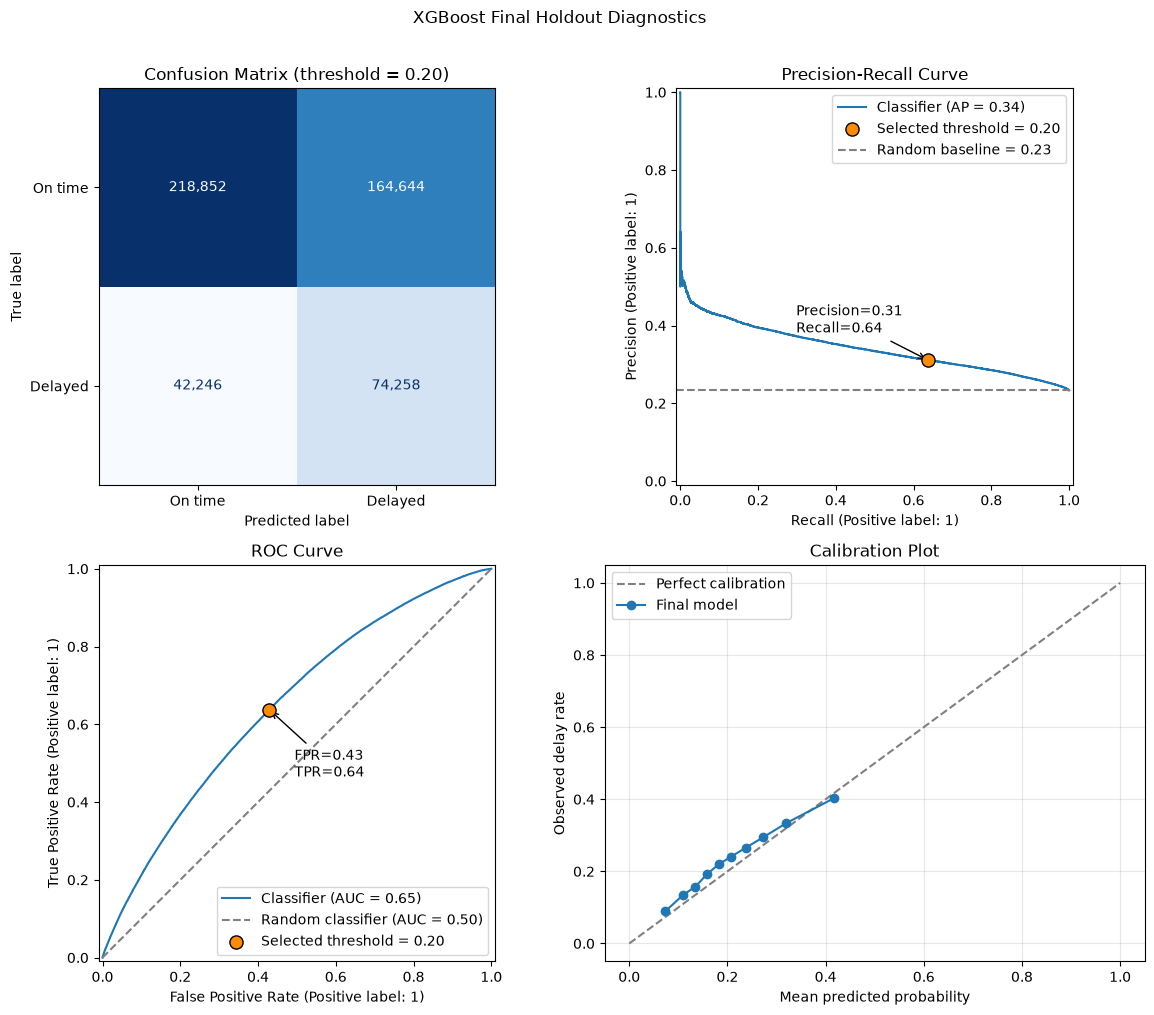

In [32]:
holdout_labels = prepared_data["y_validation"]

figure, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    holdout_labels,
    holdout_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    values_format=",d",
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    f"Confusion Matrix (threshold = {SELECTED_THRESHOLD:.2f})"
)

PrecisionRecallDisplay.from_predictions(
    holdout_labels,
    holdout_probabilities,
    ax=axes[0, 1],
)
selected_precision = float(holdout_metrics["DELAY_PRECISION"])
selected_recall = float(holdout_metrics["DELAY_RECALL"])
axes[0, 1].scatter(
    selected_recall,
    selected_precision,
    s=90,
    color="darkorange",
    edgecolor="black",
    zorder=5,
    label=f"Selected threshold = {SELECTED_THRESHOLD:.2f}",
)
axes[0, 1].axhline(
    holdout_prevalence,
    linestyle="--",
    color="gray",
    label=f"Random baseline = {holdout_prevalence:.2f}",
)
axes[0, 1].annotate(
    f"Precision={selected_precision:.2f}\nRecall={selected_recall:.2f}",
    (selected_recall, selected_precision),
    xytext=(-95, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
axes[0, 1].set_title("Precision-Recall Curve")
axes[0, 1].legend(loc="upper right")

RocCurveDisplay.from_predictions(
    holdout_labels,
    holdout_probabilities,
    ax=axes[1, 0],
)
selected_fpr = float(
    holdout_metrics["FP"]
    / (holdout_metrics["FP"] + holdout_metrics["TN"])
)
selected_tpr = selected_recall
axes[1, 0].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random classifier (AUC = 0.50)",
)
axes[1, 0].scatter(
    selected_fpr,
    selected_tpr,
    s=90,
    color="darkorange",
    edgecolor="black",
    zorder=5,
    label=f"Selected threshold = {SELECTED_THRESHOLD:.2f}",
)
axes[1, 0].annotate(
    f"FPR={selected_fpr:.2f}\nTPR={selected_tpr:.2f}",
    (selected_fpr, selected_tpr),
    xytext=(18, -48),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
axes[1, 0].set_title("ROC Curve")
axes[1, 0].legend(loc="lower right")

observed_rates, predicted_probabilities = calibration_curve(
    holdout_labels,
    holdout_probabilities,
    n_bins=cfg.CALIBRATION_BINS,
    strategy="quantile",
)
axes[1, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Perfect calibration",
)
axes[1, 1].plot(
    predicted_probabilities,
    observed_rates,
    marker="o",
    label="Final model",
)
axes[1, 1].set_xlabel("Mean predicted probability")
axes[1, 1].set_ylabel("Observed delay rate")
axes[1, 1].set_title("Calibration Plot")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

figure.suptitle(
    f"{SELECTED_MODEL_NAME} Final Holdout Diagnostics",
    y=1.01,
)
figure.tight_layout()
plt.show()


## Frozen Threshold Versus the Default Threshold

This comparison explains the operational effect of the selected threshold. It does not search for a new threshold.


In [33]:
threshold_comparison = pd.DataFrame(
    [
        {
            "THRESHOLD_POLICY": "Frozen Notebook 07 threshold",
            "THRESHOLD": SELECTED_THRESHOLD,
            **holdout_metrics,
        },
        {
            "THRESHOLD_POLICY": "Default classifier threshold",
            "THRESHOLD": 0.50,
            **default_threshold_metrics,
        },
    ]
)

display(
    threshold_comparison[
        [
            "THRESHOLD_POLICY",
            "THRESHOLD",
            "ACCURACY",
            "DELAY_PRECISION",
            "DELAY_RECALL",
            "DELAY_F1",
            "ALERT_RATE",
        ]
    ]
)


,THRESHOLD_POLICY,THRESHOLD,ACCURACY,DELAY_PRECISION,DELAY_RECALL,DELAY_F1,ALERT_RATE
0,Frozen Notebook 07 threshold,0.2,0.586220,0.310830,0.637386,0.417877,0.477804
1,Default classifier threshold,0.5,0.766422,0.472986,0.021416,0.040976,0.010550


## Risk Concentration and Subgroup Error Analysis


In [34]:
holdout_results = holdout_pdf[
    CATEGORICAL_COLUMNS
].copy()
holdout_results["LABEL"] = holdout_labels
holdout_results["PROBABILITY"] = holdout_probabilities
holdout_results["PREDICTION"] = holdout_predictions

lift_results = lift_at_top_percentiles(
    pd.Series(holdout_labels),
    pd.Series(holdout_probabilities),
    cfg.TOP_RISK_PERCENTILES,
)

subgroup_columns = [
    column
    for column in [
        cfg.AIRLINE_COLUMN,
        cfg.ORIGIN_COLUMN,
        cfg.TIME_OF_DAY_COLUMN,
    ]
    if column in holdout_results.columns
]
subgroup_results = subgroup_error_analysis(
    frame=holdout_results,
    group_columns=subgroup_columns,
    label_column="LABEL",
    probability_column="PROBABILITY",
    threshold=SELECTED_THRESHOLD,
    min_group_size=500,
)

display(lift_results)
display(subgroup_results.head(30))


,top_percent,flight_count,observed_delay_rate,delay_recall,lift
0,0.05,25000.0,0.42912,0.092083,1.841654
1,0.10,50000.0,0.40288,0.172904,1.729039
2,0.20,100000.0,0.36850,0.316298,1.581491


,subgroup_type,subgroup_value,flight_count,delay_rate,mean_predicted_probability,delay_recall,delay_precision
6,OP_UNIQUE_CARRIER,HA,5783.0,0.239495,0.152079,0.273646,0.367961
3,OP_UNIQUE_CARRIER,DL,73926.0,0.211576,0.178487,0.463334,0.303616
10,OP_UNIQUE_CARRIER,OO,58830.0,0.223355,0.183376,0.493379,0.306062
7,OP_UNIQUE_CARRIER,MQ,21743.0,0.204434,0.196318,0.553206,0.265551
11,OP_UNIQUE_CARRIER,UA,58345.0,0.210198,0.211132,0.623614,0.279328
1,OP_UNIQUE_CARRIER,AS,18090.0,0.235766,0.209867,0.633998,0.285112
8,OP_UNIQUE_CARRIER,NK,10284.0,0.276935,0.215957,0.650983,0.357639
12,OP_UNIQUE_CARRIER,WN,99967.0,0.219312,0.200924,0.676063,0.319488
2,OP_UNIQUE_CARRIER,B6,17608.0,0.302590,0.241409,0.729354,0.375133
5,OP_UNIQUE_CARRIER,G4,9180.0,0.270697,0.229970,0.732394,0.350674


## Persist the Final Model and Evaluation Artifacts

The saved bundle contains the fitted XGBoost model, its preprocessing pipeline, the decision threshold, the frozen Medium/High/Critical risk cutoffs, and the January-October historical references required to score a new scheduled flight consistently.


In [35]:
calibration_results = calibration_summary(
    pd.Series(holdout_labels),
    pd.Series(holdout_probabilities),
    n_bins=cfg.CALIBRATION_BINS,
)


def write_pandas_table(
    frame: pd.DataFrame,
    table_name: str,
) -> None:
    clean = frame.copy()
    for column in clean.select_dtypes(include=["object"]).columns:
        clean[column] = clean[column].fillna("").astype(str)
    spark.createDataFrame(clean).write.format("delta").mode(
        "overwrite"
    ).option("overwriteSchema", "true").saveAsTable(table_name)


write_pandas_table(
    final_evaluation,
    cfg.FINAL_MODEL_EVALUATION_TABLE,
)
write_pandas_table(
    threshold_comparison,
    cfg.FINAL_MODEL_THRESHOLD_COMPARISON_TABLE,
)
write_pandas_table(
    calibration_results,
    cfg.FINAL_MODEL_CALIBRATION_TABLE,
)
write_pandas_table(
    lift_results,
    cfg.FINAL_MODEL_LIFT_TABLE,
)
write_pandas_table(
    subgroup_results,
    cfg.FINAL_MODEL_SUBGROUP_TABLE,
)

global_historical_rate = float(
    df_final_training.agg(F.avg(TARGET_COLUMN).alias("RATE")).first()["RATE"]
)


def build_rate_reference(
    frame: DataFrame,
    group_columns: list[str],
) -> dict[str, float]:
    grouped = (
        frame.groupBy(*group_columns)
        .agg(
            F.count("*").alias("HIST_FLIGHTS"),
            F.sum(TARGET_COLUMN).alias("HIST_DELAYS"),
        )
        .withColumn(
            "HIST_RATE",
            (
                F.col("HIST_DELAYS")
                + SMOOTHING * F.lit(global_historical_rate)
            )
            / (F.col("HIST_FLIGHTS") + F.lit(SMOOTHING)),
        )
    )
    return {
        "|".join(str(row[column]) for column in group_columns): float(
            row["HIST_RATE"]
        )
        for row in grouped.collect()
    }


route_schedule_rows = (
    df_final_training.groupBy(cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN)
    .agg(
        F.percentile_approx(cfg.DISTANCE_COLUMN, 0.5).alias("DISTANCE"),
        F.percentile_approx(
            cfg.SCHEDULED_ELAPSED_TIME_COLUMN,
            0.5,
        ).alias("SCHEDULED_ELAPSED_TIME"),
    )
    .collect()
)
route_schedule_reference = {
    f"{row[cfg.ORIGIN_COLUMN]}|{row[cfg.DESTINATION_COLUMN]}": {
        "distance": float(row["DISTANCE"]),
        "scheduled_elapsed_time": float(row["SCHEDULED_ELAPSED_TIME"]),
    }
    for row in route_schedule_rows
    if row["DISTANCE"] is not None
    and row["SCHEDULED_ELAPSED_TIME"] is not None
}

airline_route_reference = {}
for row in (
    df_final_training
    .select(cfg.AIRLINE_COLUMN, cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN)
    .distinct()
    .collect()
):
    route_key = f"{row[cfg.ORIGIN_COLUMN]}|{row[cfg.DESTINATION_COLUMN]}"
    airline_route_reference.setdefault(row[cfg.AIRLINE_COLUMN], []).append(route_key)
for airline in airline_route_reference:
    airline_route_reference[airline] = sorted(airline_route_reference[airline])

inference_reference = {
    "as_of_date": str(cfg.VALIDATION_END_DATE),
    "global_delay_rate": global_historical_rate,
    "airline_delay_rates": build_rate_reference(
        df_final_training, [cfg.AIRLINE_COLUMN]
    ),
    "origin_delay_rates": build_rate_reference(
        df_final_training, [cfg.ORIGIN_COLUMN]
    ),
    "destination_delay_rates": build_rate_reference(
        df_final_training, [cfg.DESTINATION_COLUMN]
    ),
    "route_delay_rates": build_rate_reference(
        df_final_training,
        [cfg.ORIGIN_COLUMN, cfg.DESTINATION_COLUMN],
    ),
    "route_schedule": route_schedule_reference,
    "airline_routes": airline_route_reference,
}

contract_input = holdout_pdf[CATEGORICAL_COLUMNS + NUMERICAL_COLUMNS].head(5).copy()
contract_encoded = prepared_data["preprocessor"].transform(contract_input)
contract_probabilities = final_model.predict_proba(contract_encoded)[:, 1]
serving_contract = [
    {
        "model_input": row.to_dict(),
        "expected_probability": float(probability),
    }
    for (_, row), probability in zip(
        contract_input.iterrows(), contract_probabilities
    )
]

model_bundle = {
    "model": final_model,
    "preprocessor": prepared_data["preprocessor"],
    "model_name": SELECTED_MODEL_NAME,
    "parameters": SELECTED_MODEL_PARAMETERS,
    "decision_threshold": SELECTED_THRESHOLD,
    "risk_thresholds": RISK_THRESHOLDS,
    "categorical_features": CATEGORICAL_COLUMNS,
    "numerical_features": NUMERICAL_COLUMNS,
    "target": TARGET_COLUMN,
    "inference_reference": inference_reference,
    "serving_contract": serving_contract,
}

metadata_payload = {
    "model_name": SELECTED_MODEL_NAME,
    "configuration_id": candidate_selection["configuration_id"],
    "parameters": SELECTED_MODEL_PARAMETERS,
    "decision_threshold": SELECTED_THRESHOLD,
    "risk_thresholds": RISK_THRESHOLDS,
    "training_period": "2025-01-01 to 2025-10-31",
    "holdout_period": "2025-11-01 to 2025-12-31",
    "training_rows": int(len(final_training_pdf)),
    "holdout_rows": int(len(holdout_pdf)),
    "training_seconds": float(training_seconds),
    "candidate_source": cfg.CANDIDATE_SELECTION_PATH,
    "feature_manifest_source": cfg.MODEL_FEATURE_MANIFEST_PATH,
    "model_bundle_path": cfg.SELECTED_MODEL_BUNDLE_PATH,
    "inference_reference_as_of": inference_reference["as_of_date"],
    "inference_routes": len(route_schedule_reference),
    "random_seed": int(cfg.RANDOM_SEED),
}

metrics_payload = {
    "model_name": SELECTED_MODEL_NAME,
    "decision_threshold": SELECTED_THRESHOLD,
    "risk_thresholds": RISK_THRESHOLDS,
    "validation_metrics_from_notebook_07": candidate_selection[
        "validation_metrics"
    ],
    "holdout_metrics": {
        key.lower(): value
        for key, value in holdout_metrics.items()
    },
    "default_threshold_holdout_metrics": {
        key.lower(): value
        for key, value in default_threshold_metrics.items()
    },
    "naive_brier_score": naive_brier_score,
    "metric_source": (
        "November-December 2025 holdout evaluated once "
        "with the frozen Notebook 07 model decision"
    ),
}


def artifact_client() -> WorkspaceClient:
    try:
        dbutils
    except NameError:
        if LOCAL_DATABRICKS_HOST and LOCAL_DATABRICKS_TOKEN:
            return WorkspaceClient(
                host=LOCAL_DATABRICKS_HOST,
                token=LOCAL_DATABRICKS_TOKEN,
                auth_type="pat",
            )
        return WorkspaceClient(profile=DATABRICKS_PROFILE)
    return WorkspaceClient()


client = artifact_client()
client.files.create_directory(cfg.SELECTED_MODEL_PATH)

bundle_buffer = io.BytesIO()
joblib.dump(model_bundle, bundle_buffer, compress=3)
bundle_buffer.seek(0)
client.files.upload(
    cfg.SELECTED_MODEL_BUNDLE_PATH,
    bundle_buffer,
    overwrite=True,
)

for artifact_path, payload in [
    (cfg.SELECTED_MODEL_METADATA_PATH, metadata_payload),
    (cfg.SELECTED_MODEL_METRICS_PATH, metrics_payload),
]:
    content = json.dumps(
        payload,
        indent=2,
        sort_keys=True,
    ).encode("utf-8")
    client.files.upload(
        artifact_path,
        io.BytesIO(content),
        overwrite=True,
    )

print(f"Model bundle: {cfg.SELECTED_MODEL_BUNDLE_PATH}")
print(f"Model metadata: {cfg.SELECTED_MODEL_METADATA_PATH}")
print(f"Model metrics: {cfg.SELECTED_MODEL_METRICS_PATH}")
print(f"Evaluation table: {cfg.FINAL_MODEL_EVALUATION_TABLE}")


Model bundle: /Volumes/workspace/default/flight_delay_capstone/models/xgboost_final/model_bundle.joblib
Model metadata: /Volumes/workspace/default/flight_delay_capstone/models/xgboost_final/model_metadata.json
Model metrics: /Volumes/workspace/default/flight_delay_capstone/models/xgboost_final/model_metrics.json
Evaluation table: workspace.default.flight_delay_final_model_evaluation


## RQ1 Final Interpretation

The holdout results answer RQ1 as a **moderate, useful risk-ranking result**, not
as near-perfect classification. Evidence of value requires ROC-AUC above 0.50,
PR-AUC above the holdout delay prevalence, probability calibration better than
the naive prevalence forecast, and meaningful lift in the highest-risk group.
The confusion matrix states the operational precision–recall trade-off at the
threshold frozen in Notebook 07.


## Completion Criteria

Notebook 08 is complete when:

- the V1 candidate metadata and feature manifest are loaded;
- XGBoost is retrained using January-October history;
- the frozen threshold is applied without modification;
- all required holdout metrics and plots are produced;
- the model bundle and evaluation artifacts are saved successfully.

After these results are reviewed, they must not be used to repeat model selection or tuning.


In [36]:
if abs(SELECTED_THRESHOLD - float(
    candidate_selection["decision_threshold"]
)) > 1e-12:
    raise RuntimeError("The frozen Notebook 07 threshold changed unexpectedly.")

if holdout_metrics["BRIER_SCORE"] >= naive_brier_score:
    print(
        "Warning: the final model does not improve on the naive "
        "holdout Brier Score."
    )

gc.collect()

print("Notebook 08 completed successfully.")
print("The holdout evaluation is now final and should not trigger retuning.")


Notebook 08 completed successfully.
The holdout evaluation is now final and should not trigger retuning.
